In [1]:
packages <- c("ggplot2", "dplyr", "tidyr", "arrow")
for (pkg in packages) {
    suppressMessages(
        suppressWarnings(
            library(pkg, character.only = TRUE)
    )   )
}

In [2]:
feature_importances_df = arrow::read_parquet(
    file.path("../model_results/combined_feature_importances.parquet"))
model_performance_df = arrow::read_parquet(file.path("../model_results/combined_model_performance.parquet"))
summary_metrics_df = arrow::read_parquet(file.path("../model_results/combined_summary_metrics.parquet"))

# predicted_viabilities_df carries every feature column (~19.5k) alongside the
# metadata/predictions we actually plot - slim it down once here so every
# downstream ggplot() call isn't dragging that width along.
predicted_viabilities_df = arrow::read_parquet(
    file.path("../model_results/combined_predicted_viabilities.parquet"),
    col_select = c(
        Metadata_Biology_PatientTumor, Metadata_Experiment_Treatment,
        Metadata_Experiment_Dose, Metadata_Experiment_Class,
        Metadata_Experiment_Target, Metadata_Experiment_TherapeuticCategories,
        Metadata_fold, Metadata_held_out_group, Metadata_split_method,
        Metadata_shuffle_status, Metadata_profile_type,
        Actual_Viability, Predicted_Viability
    )
)

In [3]:
# ---------------------------------------------------------------------
# Classify each profile by what kind of features it's built from, so the
# performance plots can break results out by feature type (handcrafted
# ZedProfiler measurements vs. foundation-model embeddings) the same way
# the predicted-vs-actual plots already break results out by profile.
# ---------------------------------------------------------------------
add_feature_type <- function(df, x) {
    #' Add a column to the input data frame that classifies each profile by feature type.
    #'
    #' This function takes a data frame and adds a new column called `Metadata_feature_type`
    #' that classifies each profile based on the values in the `Metadata_profile_type` column. The classification is done using a series of conditions that check for specific keywords in the `Metadata_profile
    df %>%
        mutate(
            Metadata_feature_type = dplyr::case_when(
                # nucleocentric and sammed
                grepl("sammed", x, ignore.case = TRUE) & grepl("nucleocentric", x, ignore.case = TRUE) ~ "Nucleocentric DL (SAMMed3D)",
                grepl("morphem", x, ignore.case = TRUE) & grepl("nucleocentric", x, ignore.case = TRUE) ~ "Nucleocentric DL (MorphEM)",
                grepl("sammed", x, ignore.case = TRUE) & !grepl("nucleocentric", x, ignore.case = TRUE) ~ "Masked DL (SAMMed3D)",
                !grepl("sammed", x, ignore.case = TRUE) & !grepl("nucleocentric", x, ignore.case = TRUE) ~ "Masked Handcrafted (ZedProfiler)",
                TRUE ~ "other"
            ),
            # gsub'ing underscores to spaces lets label_wrap_gen() (which
            # wraps on whitespace) actually break these labels across
            # lines in facet strips - a single long underscore_joined
            # token has nowhere to wrap and just overflows the panel.
            Metadata_profile_label = paste0(
                gsub("_", " ", x), "\n[", Metadata_feature_type, "]"
            )
        )
}

add_2D_or_3D <- function(df, x) {
    #' Add a column to the input data frame that classifies each profile as 2D or 3D.
    #'
    #' This function takes a data frame and adds a new column called `Metadata_2D_or_3D`
    #' that classifies each profile based on the values in the `Metadata_profile_type` column. The classification is done using a series of conditions that check for specific keywords in the `Metadata_profile_type` column.
    df %>%
        mutate(
            Metadata_2D_or_3D = dplyr::case_when(
                grepl("2D", x, ignore.case = TRUE) ~ "2D",
                grepl("3D", x, ignore.case = TRUE) ~ "3D",
                TRUE ~ "other"
            )
        )
}

model_performance_df      <- add_feature_type(model_performance_df, "Metadata_source_file")
summary_metrics_df        <- add_feature_type(summary_metrics_df, "Metadata_source_file")
feature_importances_df    <- add_feature_type(feature_importances_df, "Metadata_source_file")
predicted_viabilities_df  <- add_feature_type(predicted_viabilities_df, "Metadata_source_file")

model_performance_df        <- add_2D_or_3D(model_performance_df, "Metadata_source_file")
summary_metrics_df          <- add_2D_or_3D(summary_metrics_df, "Metadata_source_file")
feature_importances_df      <- add_2D_or_3D(feature_importances_df, "Metadata_source_file")
predicted_viabilities_df    <- add_2D_or_3D(predicted_viabilities_df, "Metadata_source_file")

model_performance_df %>% distinct(Metadata_profile_type, Metadata_feature_type, Metadata_2D_or_3D)

Metadata_profile_type,Metadata_feature_type,Metadata_2D_or_3D
<chr>,<chr>,<chr>
nucleocentric_morphem_norm_sc_consensus_profiles,Masked Handcrafted (ZedProfiler),other
organoid_consensus_profiles,Masked Handcrafted (ZedProfiler),other
organoid_norm_sc_consensus_profiles,Masked Handcrafted (ZedProfiler),other
sammed_nucleocentric_norm_sc_consensus_profiles,Masked Handcrafted (ZedProfiler),other
sammed_organoid_norm_sc_consensus_profiles,Masked Handcrafted (ZedProfiler),other
sammed_sc_norm_sc_consensus_profiles,Masked Handcrafted (ZedProfiler),other
sc_consensus_profiles,Masked Handcrafted (ZedProfiler),other
sc_norm_sc_consensus_profiles,Masked Handcrafted (ZedProfiler),other


In [4]:
# Keyword-based profile labeler for facet strips
label_profile_type <- function(profile_type) {
    #' Label a profile type based on keywords in the profile_type string.
    pt <- tolower(profile_type)

    dplyr::case_when(
        grepl("nucleocentric", pt) & grepl("chammi|morphem", pt) ~ "Nucleocentric MorphEM",
        grepl("nucleocentric", pt) & grepl("sammed", pt) ~ "Nucleocentric SAMMed3D",
        grepl("sammed", pt) ~ "SAMMed3D",
        grepl("morphem|chammi", pt) ~ "MorphEM",
        grepl("zedprofiler", pt) ~ "ZedProfiler",
        TRUE ~ gsub("_", " ", tools::toTitleCase(pt))
    )
}

add_feature_type <- function(df) {
    #' Add a column to the input data frame that classifies each profile by feature type.
    df %>%
        mutate(
            Metadata_feature_type = label_profile_type(Metadata_profile_type),
            Metadata_profile_label = paste0(
                label_profile_type(Metadata_profile_type),
                "\n[", Metadata_feature_type, "]"
            )
        )
}

model_performance_df   <- add_feature_type(model_performance_df)
summary_metrics_df     <- add_feature_type(summary_metrics_df)
feature_importances_df <- add_feature_type(feature_importances_df)
predicted_viabilities_df <- add_feature_type(predicted_viabilities_df)

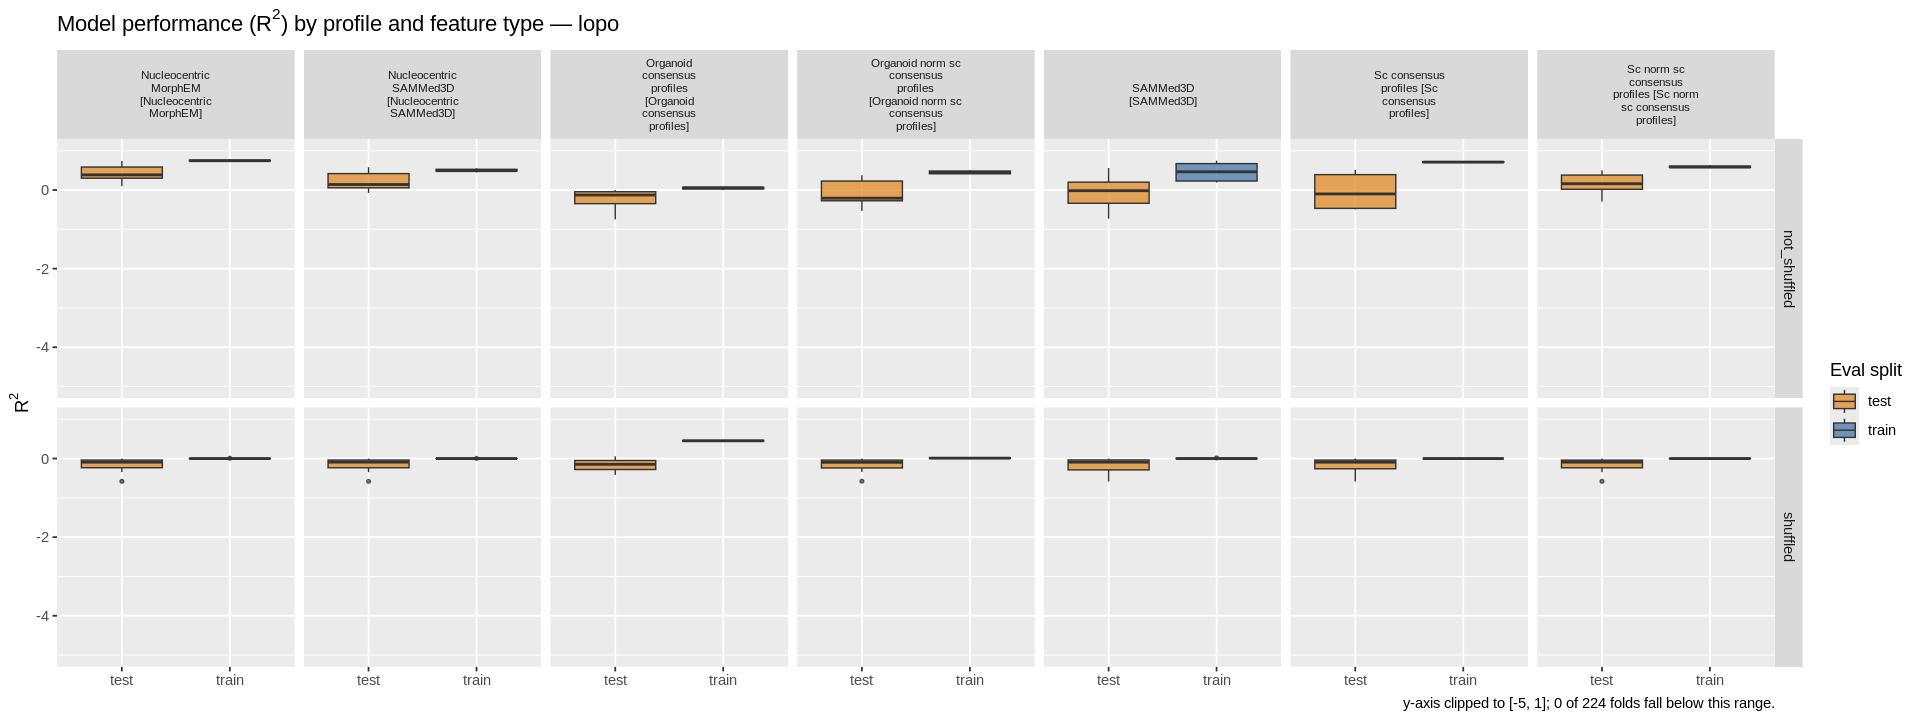

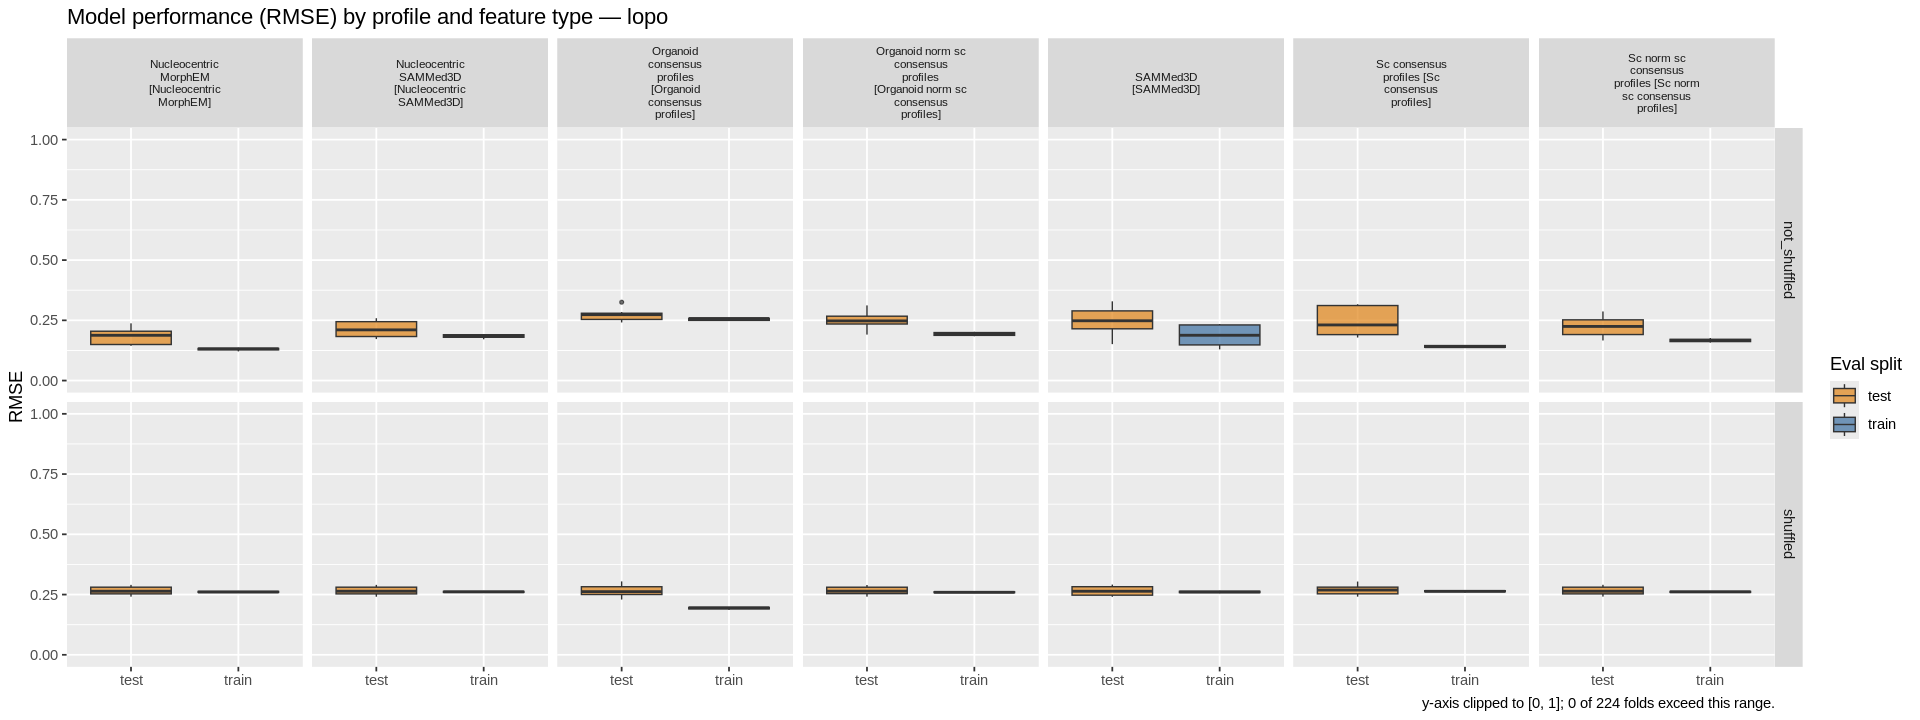

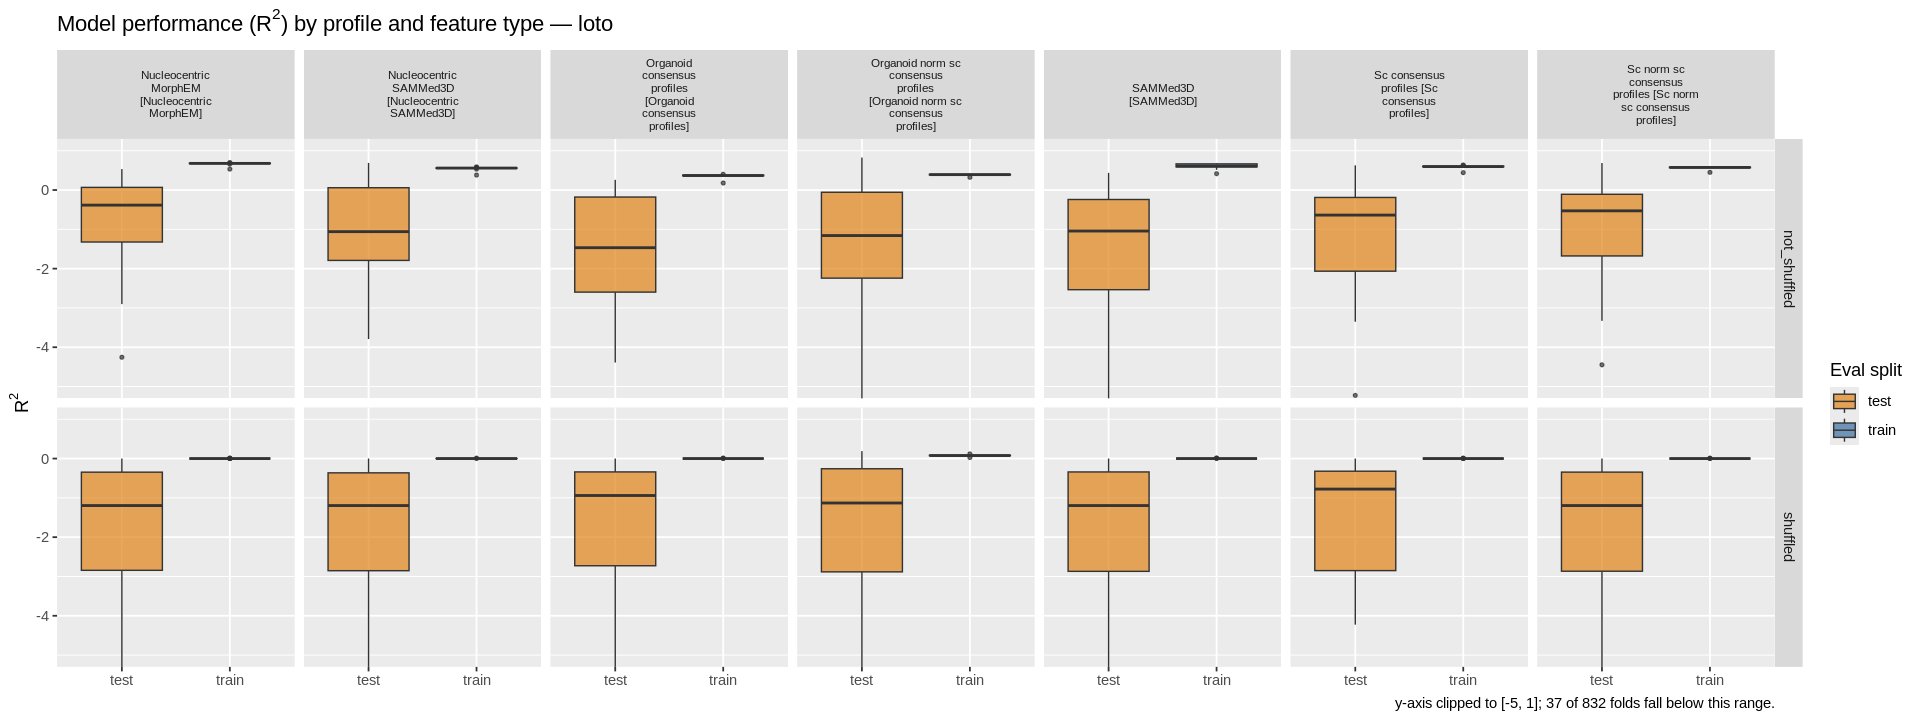

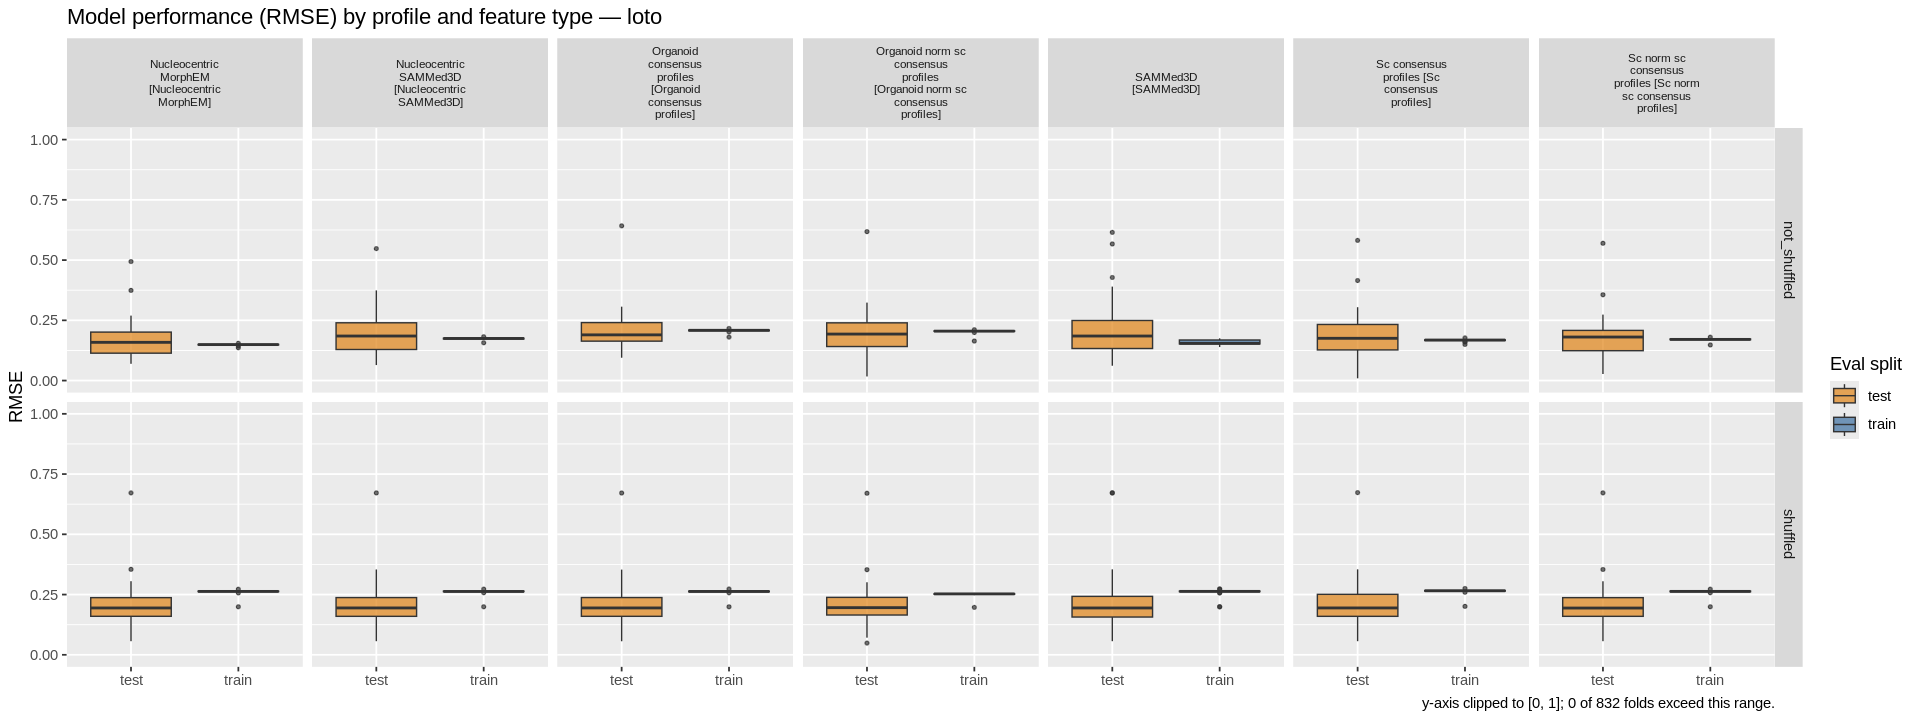

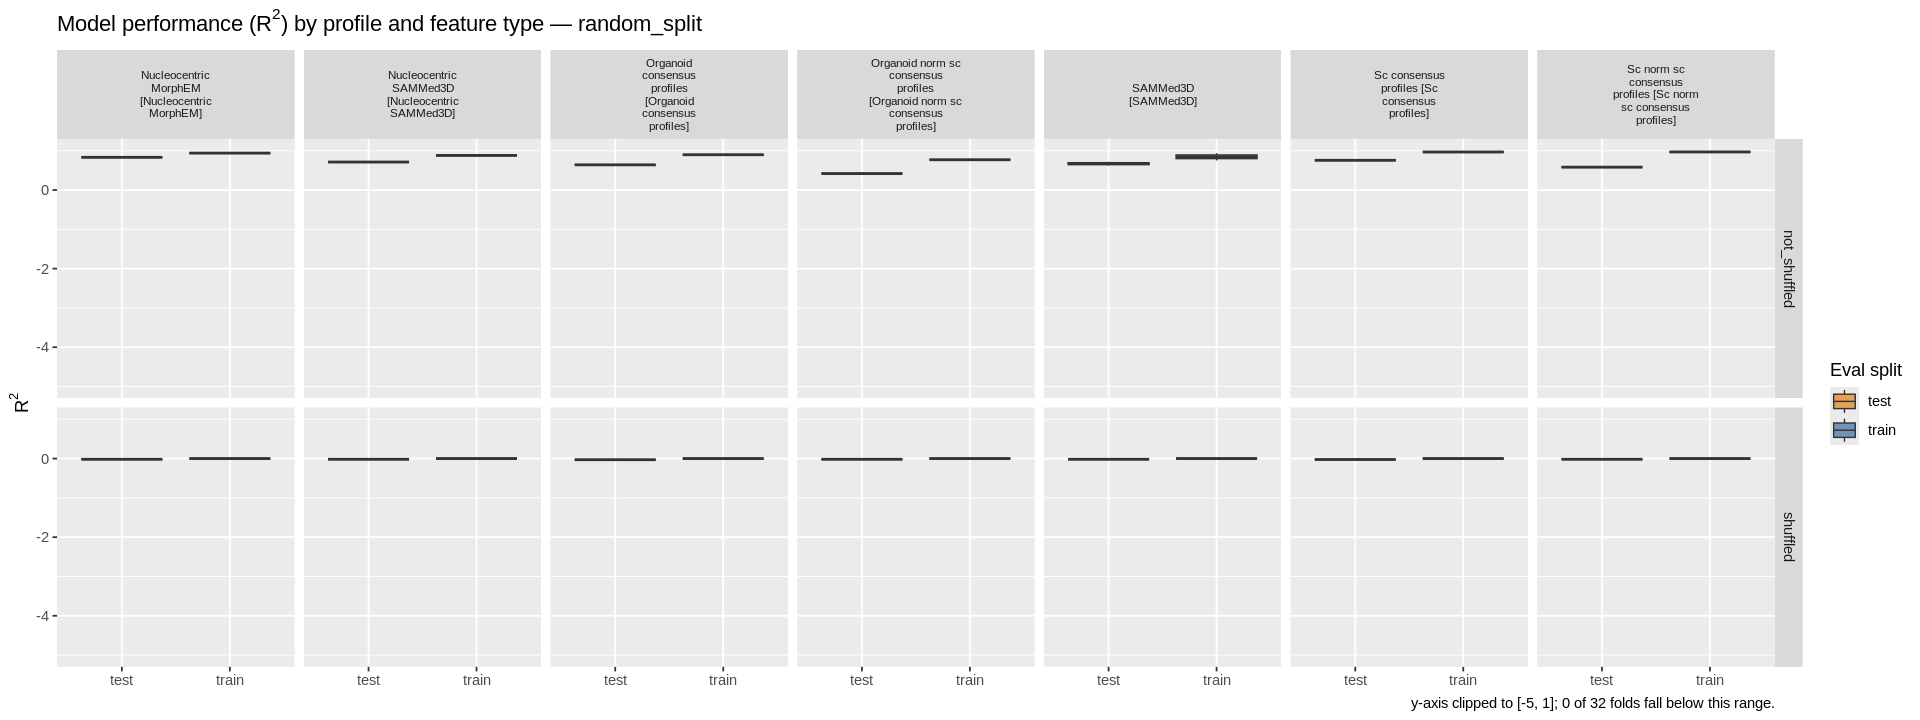

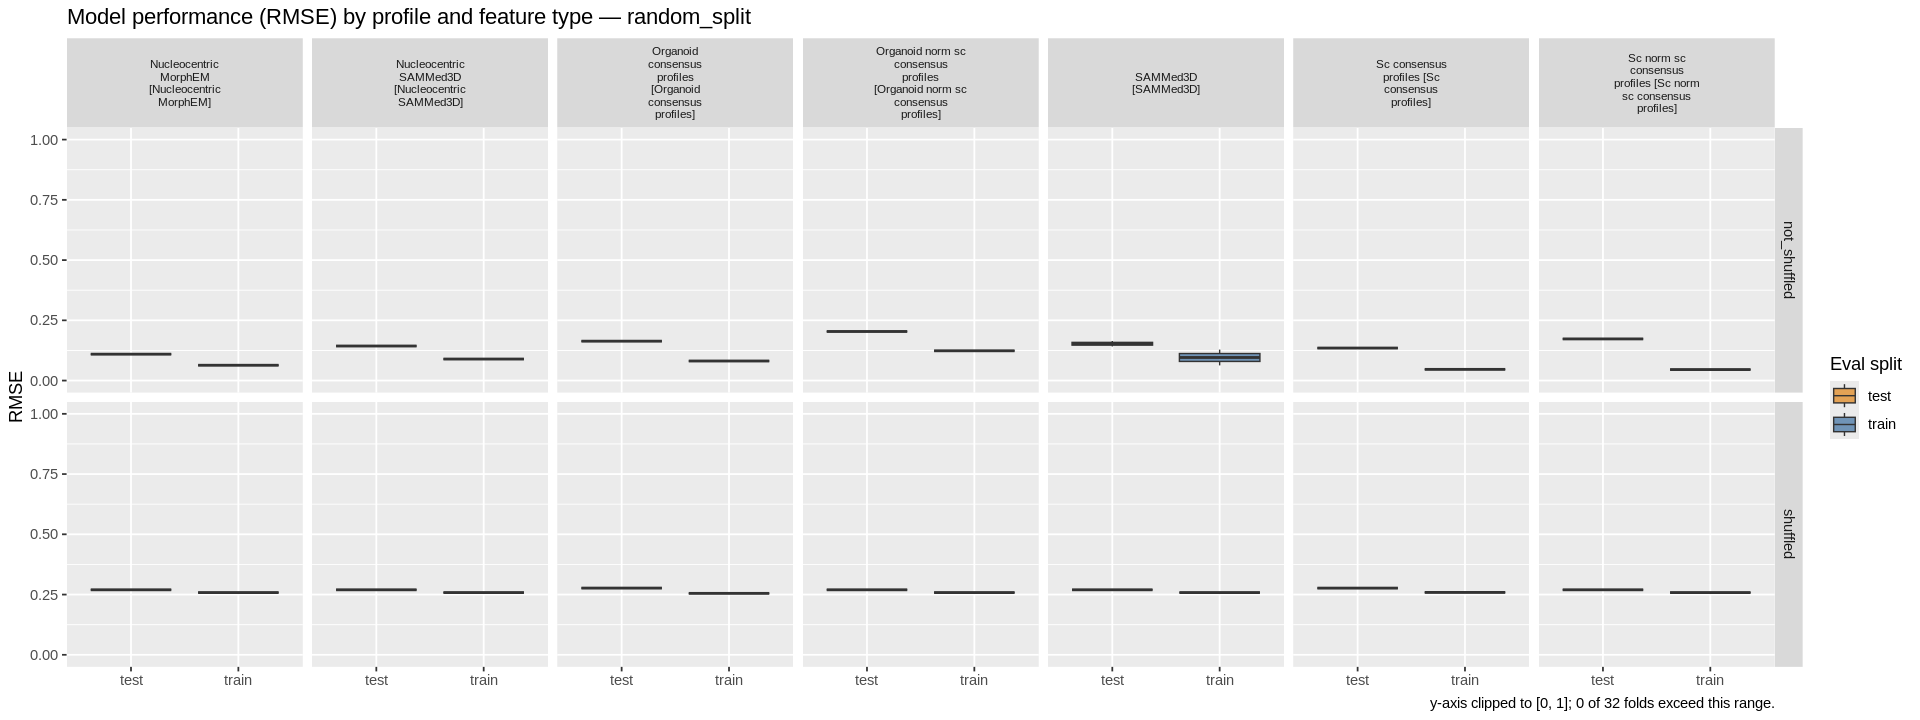

In [5]:
# ---------------------------------------------------------------------
# Per-fold model performance: R2 and RMSE by eval split, one plot per
# split method (mirroring the predicted-vs-actual plots below), faceted
# by shuffle status (rows) x profile - labeled with its feature type,
# handcrafted ZedProfiler vs. CHAMMI/SAMMed3D embedding (columns).
#
# A handful of folds (mostly lopo/loto, tiny held-out groups) produce
# catastrophically bad fits - R2 down to ~-1e25, RMSE up to ~1e14. Those
# are real values (not a bug), but letting the scale include them
# flattens every other box to a line. A fixed, clipped viewport
# (coord_cartesian, which zooms without recomputing the boxplot stats)
# keeps the boxes readable; the caption reports how many folds fall
# outside the clipped view.
#
# Viability (and hence RMSE) is stored as a 0-1 fraction, not a 0-100
# percentage - RMSE_YLIM must be on that same scale or every real box
# collapses to a line at 0 against outlier-driven clipping bounds.
# ---------------------------------------------------------------------
options(repr.plot.width = 16, repr.plot.height = 6)

eval_split_colors <- c(
    train = "#3B6FA0",
    test  = "#E08214"
)

R2_YLIM <- c(-5, 1)
RMSE_YLIM <- c(0, 1)

for (sm in unique(model_performance_df$Metadata_split_method)) {
    df_sub <- filter(model_performance_df, Metadata_split_method == sm)

    n_r2_clipped <- sum(df_sub$R2 < R2_YLIM[1], na.rm = TRUE)
    r2_plot <- (
        ggplot(df_sub, aes(x = Metadata_eval_split, y = R2, fill = Metadata_eval_split))
        + geom_boxplot(alpha = 0.7, outlier.size = 0.8, linewidth = 0.4)
        + facet_grid(
            Metadata_shuffle_status ~ Metadata_profile_label,
            labeller = labeller(Metadata_profile_label = label_wrap_gen(width = 18))
        )
        + coord_cartesian(ylim = R2_YLIM)
        + scale_fill_manual(values = eval_split_colors, name = "Eval split")
        + labs(
            x = NULL,
            y = expression(R^2),
            title = bquote("Model performance (" * R^2 * ") by profile and feature type — " * .(sm)),
            caption = paste0(
                "y-axis clipped to [", R2_YLIM[1], ", ", R2_YLIM[2], "]; ",
                n_r2_clipped, " of ", nrow(df_sub), " folds fall below this range."
            )
        )
        + theme(strip.text.x = element_text(size = 7))
    )
    ggsave(filename = paste0("r2_by_profile_", sm, ".png"), plot = r2_plot, width = 16, height = 6)
    print(r2_plot)

    n_rmse_clipped <- sum(df_sub$RMSE > RMSE_YLIM[2], na.rm = TRUE)
    rmse_plot <- (
        ggplot(df_sub, aes(x = Metadata_eval_split, y = RMSE, fill = Metadata_eval_split))
        + geom_boxplot(alpha = 0.7, outlier.size = 0.8, linewidth = 0.4)
        + facet_grid(
            Metadata_shuffle_status ~ Metadata_profile_label,
            labeller = labeller(Metadata_profile_label = label_wrap_gen(width = 18))
        )
        + coord_cartesian(ylim = RMSE_YLIM)
        + scale_fill_manual(values = eval_split_colors, name = "Eval split")
        + labs(
            x = NULL, y = "RMSE",
            title = paste0("Model performance (RMSE) by profile and feature type — ", sm),
            caption = paste0(
                "y-axis clipped to [", RMSE_YLIM[1], ", ", RMSE_YLIM[2], "]; ",
                n_rmse_clipped, " of ", nrow(df_sub), " folds exceed this range."
            )
        )
        + theme(strip.text.x = element_text(size = 7))
    )
    ggsave(filename = paste0("rmse_by_profile_", sm, ".png"), plot = rmse_plot, width = 16, height = 6)
    print(rmse_plot)
}

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`).”


...

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_segment()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`).”


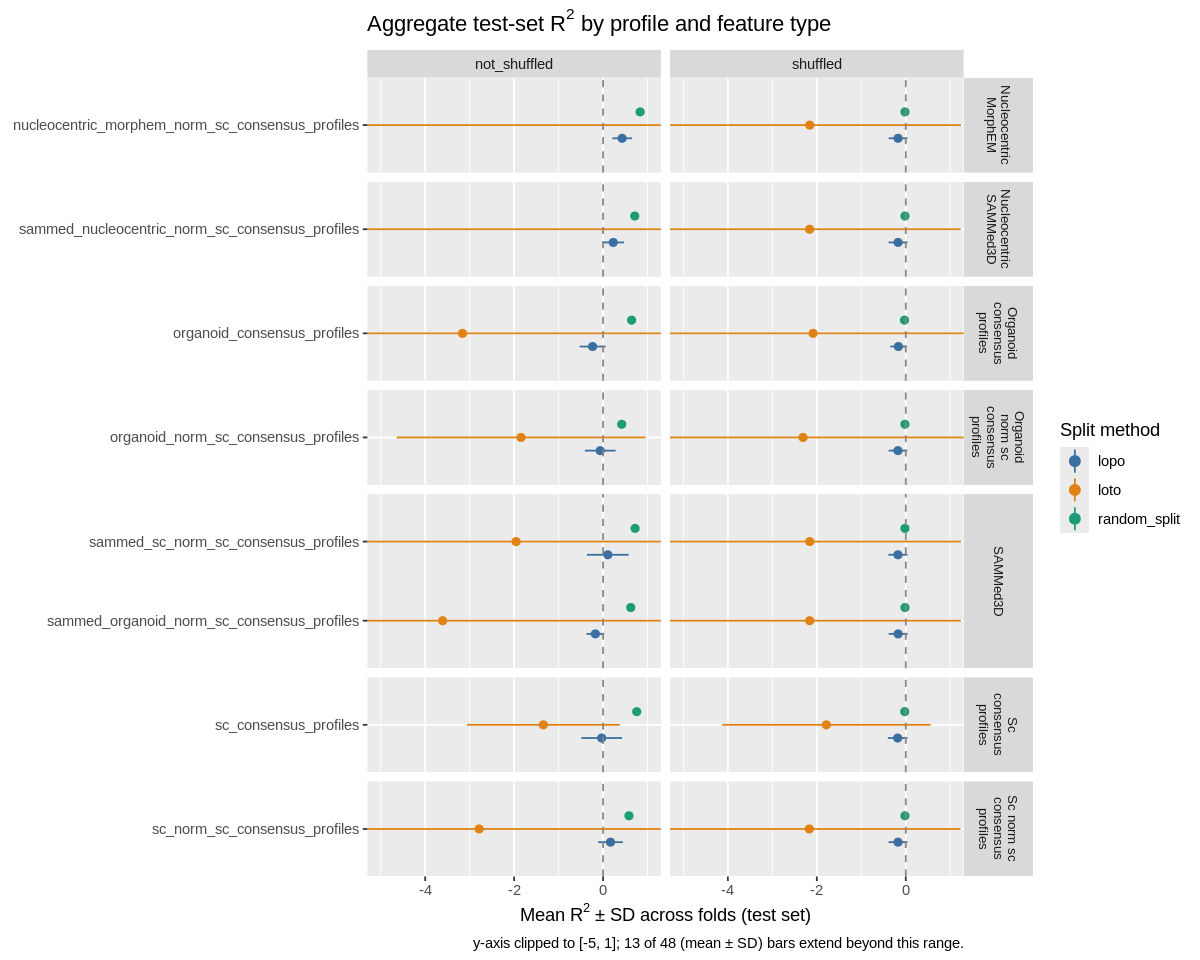

In [6]:
# ---------------------------------------------------------------------
# Aggregate test-set R2 (mean +/- SD across folds) per profile type,
# grouped by feature type (rows) and colored by split method - this is
# the one-line-per-run summary that combined_summary_metrics.parquet
# exists for.
#
# Same clipping issue as the per-fold plot above: a couple of
# (mean, SD) pairs are inflated by the same catastrophic-fold outliers,
# which blows the x-axis out to 1e25 and flattens every other error bar
# to a point. Clip the viewport the same way and disclose it.
# ---------------------------------------------------------------------
options(repr.plot.width = 10, repr.plot.height = 8)

split_method_colors <- c(
    lopo          = "#3B6FA0",
    loto          = "#E08214",
    random_split  = "#1B9E77"
)

summary_r2_df <- summary_metrics_df %>%
    select(
        Metadata_stat, Metadata_split_method, Metadata_shuffle_status,
        Metadata_profile_type, Metadata_feature_type, R2
    ) %>%
    pivot_wider(names_from = Metadata_stat, values_from = R2) %>%
    rename(R2_mean = mean, R2_sd = std)

SUMMARY_R2_XLIM <- c(-5, 1)
n_summary_clipped <- sum(
    (summary_r2_df$R2_mean - summary_r2_df$R2_sd) < SUMMARY_R2_XLIM[1] |
        (summary_r2_df$R2_mean + summary_r2_df$R2_sd) > SUMMARY_R2_XLIM[2],
    na.rm = TRUE
)

summary_plot <- (
    ggplot(
        summary_r2_df,
        aes(x = reorder(Metadata_profile_type, R2_mean), y = R2_mean, color = Metadata_split_method)
    )
    + geom_pointrange(
        aes(ymin = R2_mean - R2_sd, ymax = R2_mean + R2_sd),
        position = position_dodge(width = 0.5),
        fatten = 2.5
    )
    + geom_hline(yintercept = 0, linetype = "dashed", color = "#898781")
    + facet_grid(
        Metadata_feature_type ~ Metadata_shuffle_status, scales = "free_y", space = "free_y",
        labeller = labeller(Metadata_feature_type = label_wrap_gen(width = 12))
    )
    + coord_flip(ylim = SUMMARY_R2_XLIM)
    + scale_color_manual(values = split_method_colors, name = "Split method")
    + labs(
        x = NULL,
        y = expression("Mean " * R^2 * " ± SD across folds (test set)"),
        title = expression("Aggregate test-set " * R^2 * " by profile and feature type"),
        caption = paste0(
            "y-axis clipped to [", SUMMARY_R2_XLIM[1], ", ", SUMMARY_R2_XLIM[2], "]; ",
            n_summary_clipped, " of ", nrow(summary_r2_df), " (mean ± SD) bars extend beyond this range."
        )
    )
    + theme(strip.text.y = element_text(size = 8))
)
ggsave(filename = "summary_r2_by_profile.png", plot = summary_plot, width = 10, height = 8)
summary_plot

Metadata_profile_type,Metadata_feature_type,Metadata_split_method,Metadata_shuffle_status,n,n_predictions_clipped,pooled_R2,pooled_RMSE,pooled_MAE
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
nucleocentric_morphem_norm_sc_consensus_profiles,Nucleocentric MorphEM,lopo,not_shuffled,368,2,0.50361987,0.1842792,0.14584842
sammed_nucleocentric_norm_sc_consensus_profiles,Nucleocentric SAMMed3D,lopo,not_shuffled,368,0,0.31632634,0.2162686,0.17152609
sc_norm_sc_consensus_profiles,Sc norm sc consensus profiles,lopo,not_shuffled,368,8,0.25497912,0.2257633,0.17488396
sammed_sc_norm_sc_consensus_profiles,SAMMed3D,lopo,not_shuffled,368,18,0.24247657,0.2276497,0.16876808
sc_consensus_profiles,Sc consensus profiles,lopo,not_shuffled,360,0,0.08633057,0.2523669,0.19596297
organoid_norm_sc_consensus_profiles,Organoid norm sc consensus profiles,lopo,not_shuffled,368,4,0.07576738,0.2514547,0.20253252
sammed_organoid_norm_sc_consensus_profiles,SAMMed3D,lopo,not_shuffled,368,2,-0.04204113,0.2670002,0.21806620
organoid_consensus_profiles,Organoid consensus profiles,lopo,not_shuffled,368,0,-0.10151449,0.2742801,0.21987972
sammed_organoid_norm_sc_consensus_profiles,SAMMed3D,lopo,shuffled,368,0,-0.03669044,0.2663138,0.21287635


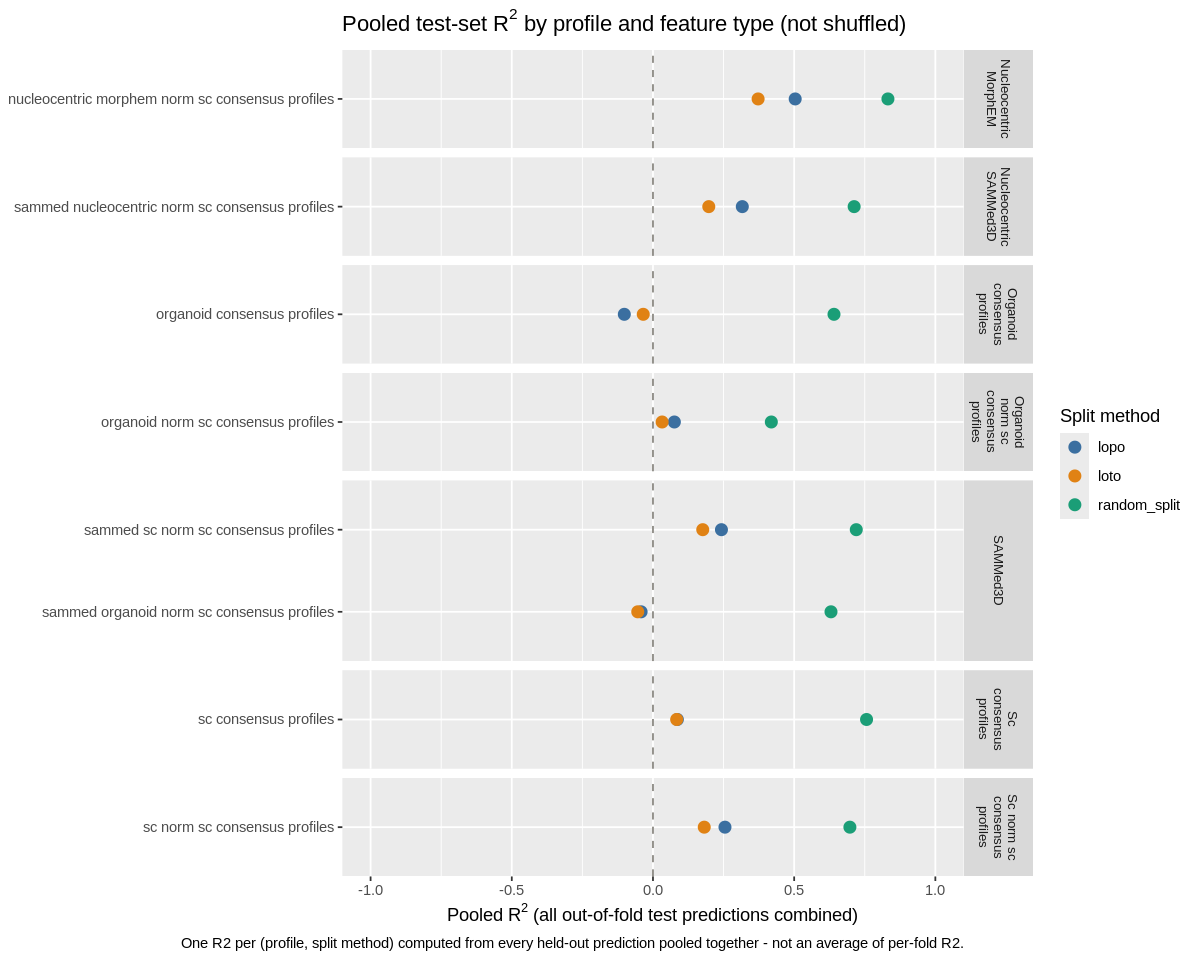

In [7]:
# ---------------------------------------------------------------------
# Pooled out-of-fold R2/RMSE/MAE per (profile, split method, shuffle
# status) - ONE metric computed from every held-out prediction pooled
# together, instead of averaging per-fold R2 like the plot above.
#
# Averaging R2 across folds is not statistically valid: R2 is a ratio of
# sums of squares, not a linear quantity, and folds vary hugely in size
# and in how much variance the held-out group's actual viability even
# has (a fold where the held-out patient has near-constant viability
# gives a near-zero SS_tot, so a small residual explodes R2 toward
# -Inf - that's the mechanism behind the R2 outliers clipped in the
# plots above). The standard fix for Leave-One-Group-Out CV is to
# concatenate every fold's out-of-fold predictions and compute a single
# R2/RMSE from the pooled set - that's what this cell does.
#
# predicted_viabilities_df carries the raw (currently unclipped)
# ElasticNet output, including the same degenerate predictions (up to
# ~1e13) documented in the R2/RMSE plots above. Computing pooled R2 on
# those raw values would just move the -1e25 problem here. Viability is
# stored as a 0-1 fraction (not a 0-100 percentage - confirmed against
# combined_predicted_viabilities.parquet, where Actual_Viability ranges
# [0, 1]), so clip predictions to [0, 1] before pooling (matching what
# the training pipeline's docstring says it does but doesn't yet
# enforce) - the number of clipped predictions is reported per group,
# so it's visible how much any given number relies on that.
# ---------------------------------------------------------------------
pooled_metrics_df <- predicted_viabilities_df %>%
    mutate(Predicted_Viability_clipped = pmin(pmax(Predicted_Viability, 0), 1)) %>%
    group_by(Metadata_profile_type, Metadata_feature_type, Metadata_split_method, Metadata_shuffle_status) %>%
    summarise(
        n = n(),
        n_predictions_clipped = sum(Predicted_Viability < 0 | Predicted_Viability > 1),
        pooled_R2 = 1 - sum((Actual_Viability - Predicted_Viability_clipped)^2) /
            sum((Actual_Viability - mean(Actual_Viability))^2),
        pooled_RMSE = sqrt(mean((Actual_Viability - Predicted_Viability_clipped)^2)),
        pooled_MAE = mean(abs(Actual_Viability - Predicted_Viability_clipped)),
        .groups = "drop"
    ) %>%
    arrange(Metadata_split_method, Metadata_shuffle_status, desc(pooled_R2))

arrow::write_parquet(pooled_metrics_df, file.path("../model_results", "pooled_performance_metrics.parquet"))

options(repr.plot.width = 10, repr.plot.height = 8)

pooled_plot <- (
    ggplot(
        filter(pooled_metrics_df, Metadata_shuffle_status == "not_shuffled"),
        aes(
            x = reorder(gsub("_", " ", Metadata_profile_type), pooled_R2),
            y = pooled_R2, color = Metadata_split_method
        )
    )
    + geom_point(size = 3)
    + geom_hline(yintercept = 0, linetype = "dashed", color = "#898781")
    + facet_grid(
        Metadata_feature_type ~ ., scales = "free_y", space = "free_y",
        labeller = labeller(Metadata_feature_type = label_wrap_gen(width = 12))
    )
    + coord_flip(ylim = c(-1, 1))
    + scale_color_manual(values = split_method_colors, name = "Split method")
    + labs(
        x = NULL, y = expression("Pooled " * R^2 * " (all out-of-fold test predictions combined)"),
        title = expression("Pooled test-set " * R^2 * " by profile and feature type (not shuffled)"),
        caption = "One R2 per (profile, split method) computed from every held-out prediction pooled together - not an average of per-fold R2."
    )
    + theme(strip.text.y = element_text(size = 8))
)
ggsave(filename = "pooled_r2_by_profile.png", plot = pooled_plot, width = 10, height = 8)
pooled_plot

pooled_metrics_df

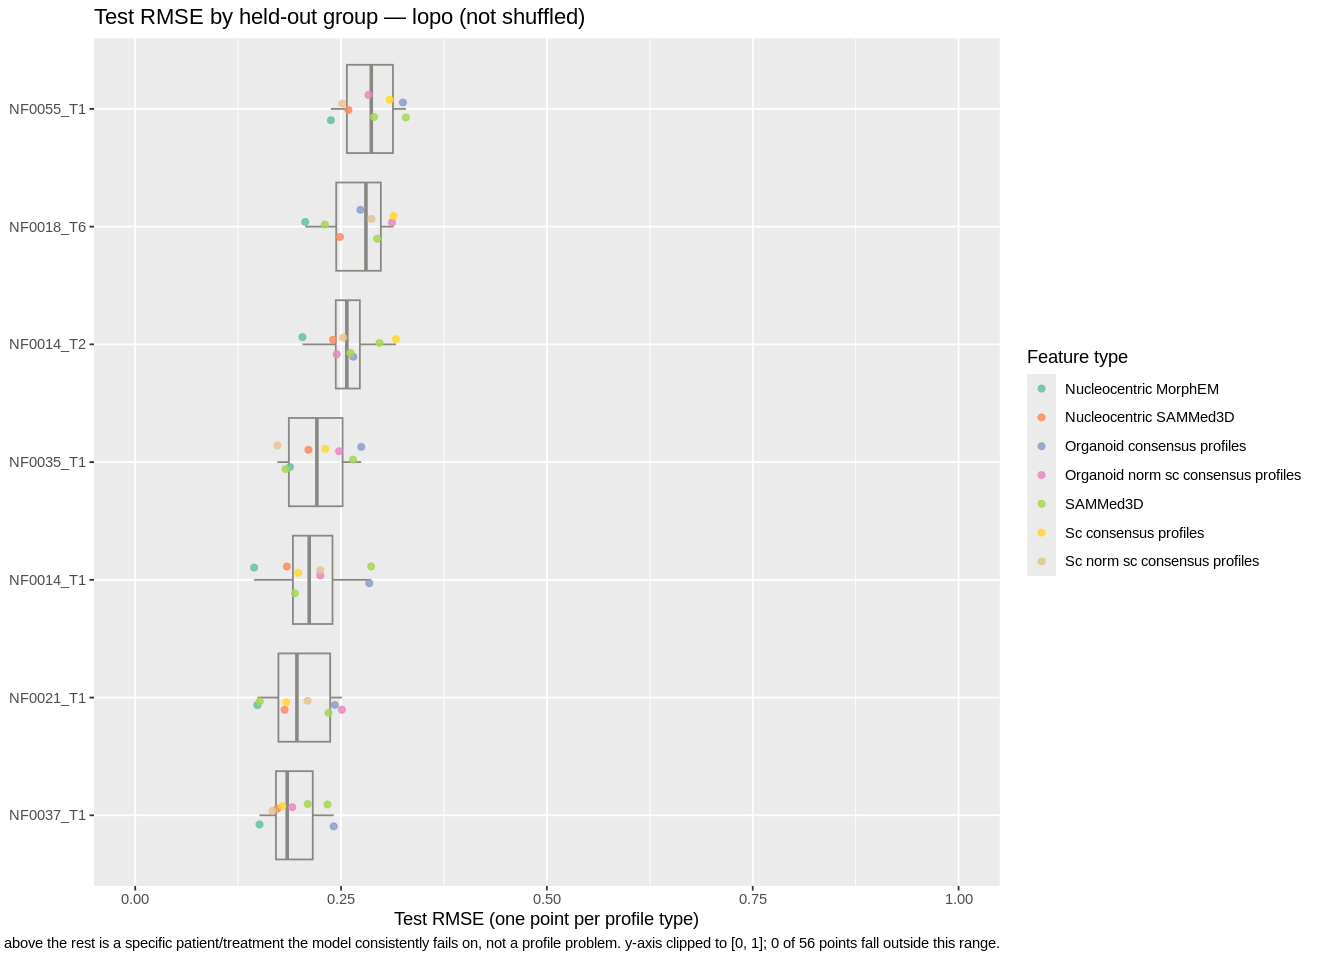

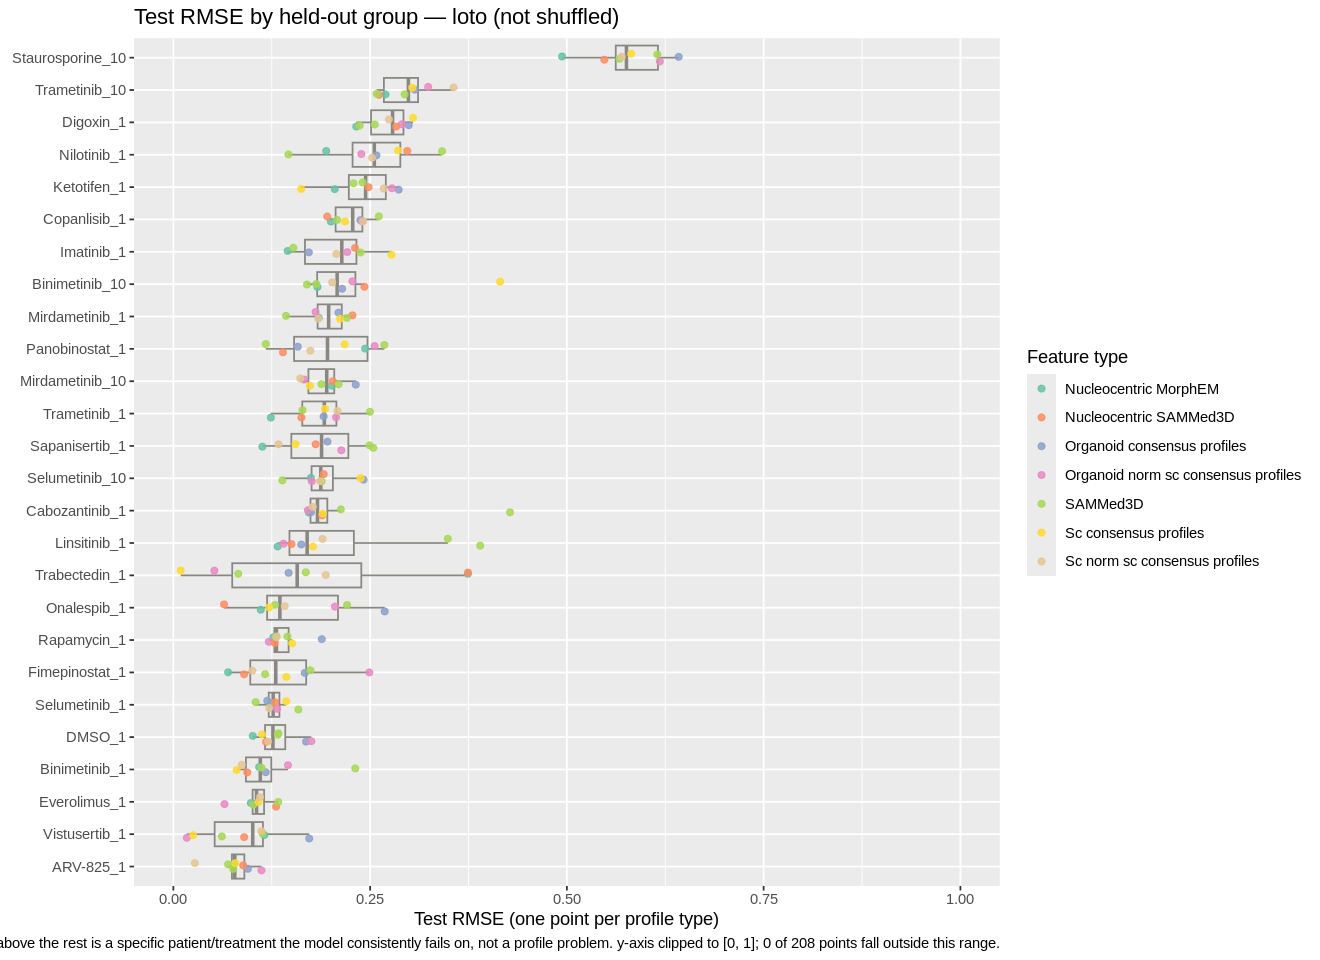

In [8]:
# ---------------------------------------------------------------------
# Per-held-out-group breakdown: is model failure spread evenly across
# patients/treatments, or concentrated in one or two of them?
#
# Every plot so far pools all folds into one number/box per profile, so
# a single catastrophic patient or treatment can drag an aggregate down
# without ever being visible on its own. model_performance_df already
# has one row per (fold, held_out_group, profile) - this just breaks it
# out by held_out_group instead of collapsing over it. random_split is
# excluded: its "held_out_group" is a single constant label (a random
# 30% holdout), not a biological group, so this breakdown isn't
# meaningful for it.
#
# RMSE is on the same 0-1 viability-fraction scale as everywhere else in
# this notebook, so the clip viewport must match.
# ---------------------------------------------------------------------
options(repr.plot.width = 11, repr.plot.height = 8)

GROUP_RMSE_YLIM <- c(0, 1)

for (sm in c("lopo", "loto")) {
    df_sub <- model_performance_df %>%
        filter(
            Metadata_split_method == sm,
            Metadata_eval_split == "test",
            Metadata_shuffle_status == "not_shuffled"
        )

    n_clipped <- sum(df_sub$RMSE > GROUP_RMSE_YLIM[2], na.rm = TRUE)

    group_plot <- (
        ggplot(
            df_sub,
            aes(x = reorder(Metadata_held_out_group, RMSE, FUN = median), y = RMSE)
        )
        + geom_boxplot(outlier.shape = NA, color = "#898781", fill = NA)
        + geom_jitter(aes(color = Metadata_feature_type), width = 0.15, height = 0, size = 1.6, alpha = 0.85)
        + coord_flip(ylim = GROUP_RMSE_YLIM)
        + scale_color_brewer(palette = "Set2", name = "Feature type")
        + labs(
            x = NULL, y = "Test RMSE (one point per profile type)",
            title = paste0("Test RMSE by held-out group — ", sm, " (not shuffled)"),
            caption = paste0(
                "Groups ordered by median RMSE across profiles; a group sitting far above the rest ",
                "is a specific patient/treatment the model consistently fails on, not a profile problem. ",
                "y-axis clipped to [", GROUP_RMSE_YLIM[1], ", ", GROUP_RMSE_YLIM[2], "]; ",
                n_clipped, " of ", nrow(df_sub), " points fall outside this range."
            )
        )
    )
    ggsave(filename = paste0("rmse_by_held_out_group_", sm, ".png"), plot = group_plot, width = 11, height = 8)
    print(group_plot)
}

Metadata_profile_type,Metadata_feature_type,Metadata_split_method,n_pairs,median_RMSE_not_shuffled,median_RMSE_shuffled,median_diff_not_minus_shuffled,p_value,p_adj,significant
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
nucleocentric_morphem_norm_sc_consensus_profiles,Nucleocentric MorphEM,lopo,7,0.1879147,0.2637290,-0.088924433,0.022494271,0.08997708,FALSE
sammed_nucleocentric_norm_sc_consensus_profiles,Nucleocentric SAMMed3D,lopo,7,0.2104382,0.2637290,-0.060604845,0.022494271,0.08997708,FALSE
sc_norm_sc_consensus_profiles,Sc norm sc consensus profiles,lopo,7,0.2247059,0.2637290,-0.038925036,0.051912965,0.13843457,FALSE
organoid_norm_sc_consensus_profiles,Organoid norm sc consensus profiles,lopo,7,0.2476365,0.2638617,-0.018949760,0.271898711,0.36253161,FALSE
sammed_sc_norm_sc_consensus_profiles,SAMMed3D,lopo,7,0.2097039,0.2637290,-0.032976974,0.271898711,0.36253161,FALSE
sc_consensus_profiles,Sc consensus profiles,lopo,7,0.2308988,0.2687339,-0.046280854,0.271898711,0.36253161,FALSE
organoid_consensus_profiles,Organoid consensus profiles,lopo,7,0.2735826,0.2620353,0.011641793,0.446872821,0.51071180,FALSE
sammed_organoid_norm_sc_consensus_profiles,SAMMed3D,lopo,7,0.2645821,0.2637290,-0.002228579,0.554113130,0.55411313,FALSE
nucleocentric_morphem_norm_sc_consensus_profiles,Nucleocentric MorphEM,loto,26,0.1586919,0.1943644,-0.037222998,0.008896873,0.07117499,FALSE


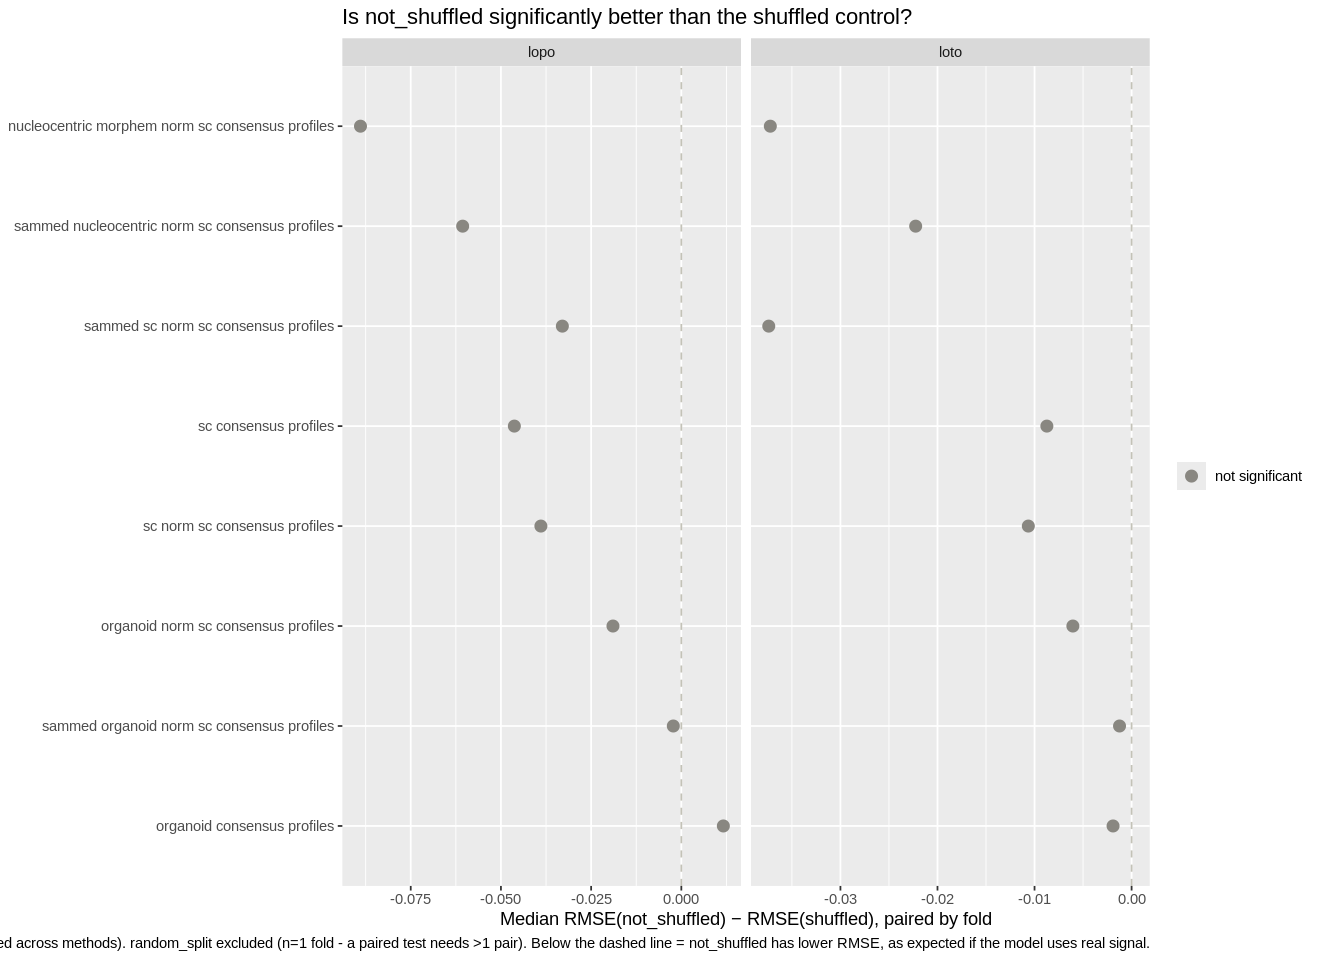

In [9]:
# ---------------------------------------------------------------------
# Is not_shuffled actually significantly better than the shuffled
# negative control, or just eyeballed as "looks different" on the plots
# above? Shuffling only permutes feature values within a column - it
# doesn't touch which rows go in which fold - so every (profile,
# split_method, fold, held_out_group) has exactly one not_shuffled RMSE
# and one shuffled RMSE. That's a natural paired design: for each such
# pair, is not_shuffled's RMSE lower? A paired Wilcoxon signed-rank test
# across folds is the right test here (small n per profile, no
# normality assumption), rather than comparing the two distributions as
# if they were independent.
#
# random_split is excluded: it has exactly one fold, so exactly one
# paired observation - wilcox.test(paired=TRUE) on n=1 doesn't test
# anything (it returns p=1 unconditionally), it isn't evidence of "no
# difference". Same reasoning as excluding it from the per-group plot.
# ---------------------------------------------------------------------
paired_df <- model_performance_df %>%
    filter(
        Metadata_eval_split == "test",
        Metadata_split_method != "random_split"
    ) %>%
    select(
        Metadata_profile_type, Metadata_feature_type, Metadata_split_method,
        Metadata_fold, Metadata_held_out_group, Metadata_shuffle_status, RMSE
    ) %>%
    pivot_wider(
        id_cols = c(
            Metadata_profile_type, Metadata_feature_type, Metadata_split_method,
            Metadata_fold, Metadata_held_out_group
        ),
        names_from = Metadata_shuffle_status,
        values_from = RMSE
    ) %>%
    tidyr::drop_na(not_shuffled, shuffled)

shuffle_test_df <- paired_df %>%
    group_by(Metadata_profile_type, Metadata_feature_type, Metadata_split_method) %>%
    summarise(
        n_pairs = n(),
        median_RMSE_not_shuffled = median(not_shuffled),
        median_RMSE_shuffled = median(shuffled),
        # negative -> not_shuffled beats shuffled (the expected direction if
        # the model is picking up real signal, not noise).
        median_diff_not_minus_shuffled = median(not_shuffled - shuffled),
        p_value = tryCatch(
            suppressWarnings(
                wilcox.test(not_shuffled, shuffled, paired = TRUE, exact = FALSE)$p.value
            ),
            error = function(e) NA_real_
        ),
        .groups = "drop"
    ) %>%
    # BH-adjust WITHIN each split method, not pooled across all of them -
    # lopo (7 folds) and loto (~26 folds) are very different-powered
    # families of tests, and pooling would let one family's tests inflate
    # or deflate the other's adjusted p-values.
    group_by(Metadata_split_method) %>%
    mutate(
        p_adj = p.adjust(p_value, method = "BH"),
        significant = !is.na(p_adj) & p_adj < 0.05
    ) %>%
    ungroup() %>%
    arrange(Metadata_split_method, p_adj)

arrow::write_parquet(shuffle_test_df, file.path("../model_results", "shuffle_significance_test.parquet"))

options(repr.plot.width = 11, repr.plot.height = 8)

STATUS_GOOD <- "#0ca30c"
STATUS_MUTED <- "#898781"

shuffle_test_plot <- (
    ggplot(
        shuffle_test_df,
        aes(
            x = reorder(gsub("_", " ", Metadata_profile_type), -median_diff_not_minus_shuffled),
            y = median_diff_not_minus_shuffled, color = significant
        )
    )
    + geom_hline(yintercept = 0, linetype = "dashed", color = "#c3c2b7")
    + geom_point(size = 3)
    + coord_flip()
    + facet_wrap(~Metadata_split_method, scales = "free_x")
    + scale_color_manual(
        values = c("TRUE" = STATUS_GOOD, "FALSE" = STATUS_MUTED),
        labels = c("TRUE" = "significant (BH q<0.05)", "FALSE" = "not significant"),
        name = NULL
    )
    + labs(
        x = NULL,
        y = "Median RMSE(not_shuffled) − RMSE(shuffled), paired by fold",
        title = "Is not_shuffled significantly better than the shuffled control?",
        caption = paste0(
            "Paired Wilcoxon signed-rank test per (profile, split method) across matched folds; ",
            "p-values BH-adjusted within each split method (not pooled across methods). ",
            "random_split excluded (n=1 fold - a paired test needs >1 pair). ",
            "Below the dashed line = not_shuffled has lower RMSE, as expected if the model uses real signal."
        )
    )
)
ggsave(filename = "shuffle_significance_by_profile.png", plot = shuffle_test_plot, width = 11, height = 8)
shuffle_test_plot

shuffle_test_df

In [10]:
# average each feature's coefficient across folds first (a single fold's
# coefficient is noisy), THEN rank by |mean coefficient| per profile type -
# ranking on per-fold values (as before) let one noisy fold's outlier
# coefficient dominate the "top features" list.
feature_importance_avg_df <- feature_importances_df %>%
    group_by(Metadata_profile_type, feature) %>%
    summarise(mean_importance = mean(importance), .groups = "drop") %>%
    mutate(abs_importance = abs(mean_importance))

top_features_df <- feature_importance_avg_df %>%
    group_by(Metadata_profile_type) %>%
    slice_max(order_by = abs_importance, n = 10, with_ties = FALSE) %>%
    ungroup()

head(top_features_df)

Metadata_profile_type,feature,mean_importance,abs_importance
<chr>,<chr>,<dbl>,<dbl>
nucleocentric_morphem_norm_sc_consensus_profiles,Nucleocentric_DNA_CHAMMI75_Feature98,0.015620590,0.015620590
nucleocentric_morphem_norm_sc_consensus_profiles,Nucleocentric_DNA_CHAMMI75_Feature264,0.013165009,0.013165009
nucleocentric_morphem_norm_sc_consensus_profiles,Nucleocentric_DNA_CHAMMI75_Feature256,-0.011735324,0.011735324
nucleocentric_morphem_norm_sc_consensus_profiles,Nucleocentric_AGP_CHAMMI75_Feature20,0.005657388,0.005657388
nucleocentric_morphem_norm_sc_consensus_profiles,Nucleocentric_DNA_CHAMMI75_Feature184,-0.005148673,0.005148673
nucleocentric_morphem_norm_sc_consensus_profiles,Nucleocentric_DNA_CHAMMI75_Feature77,0.004909105,0.004909105


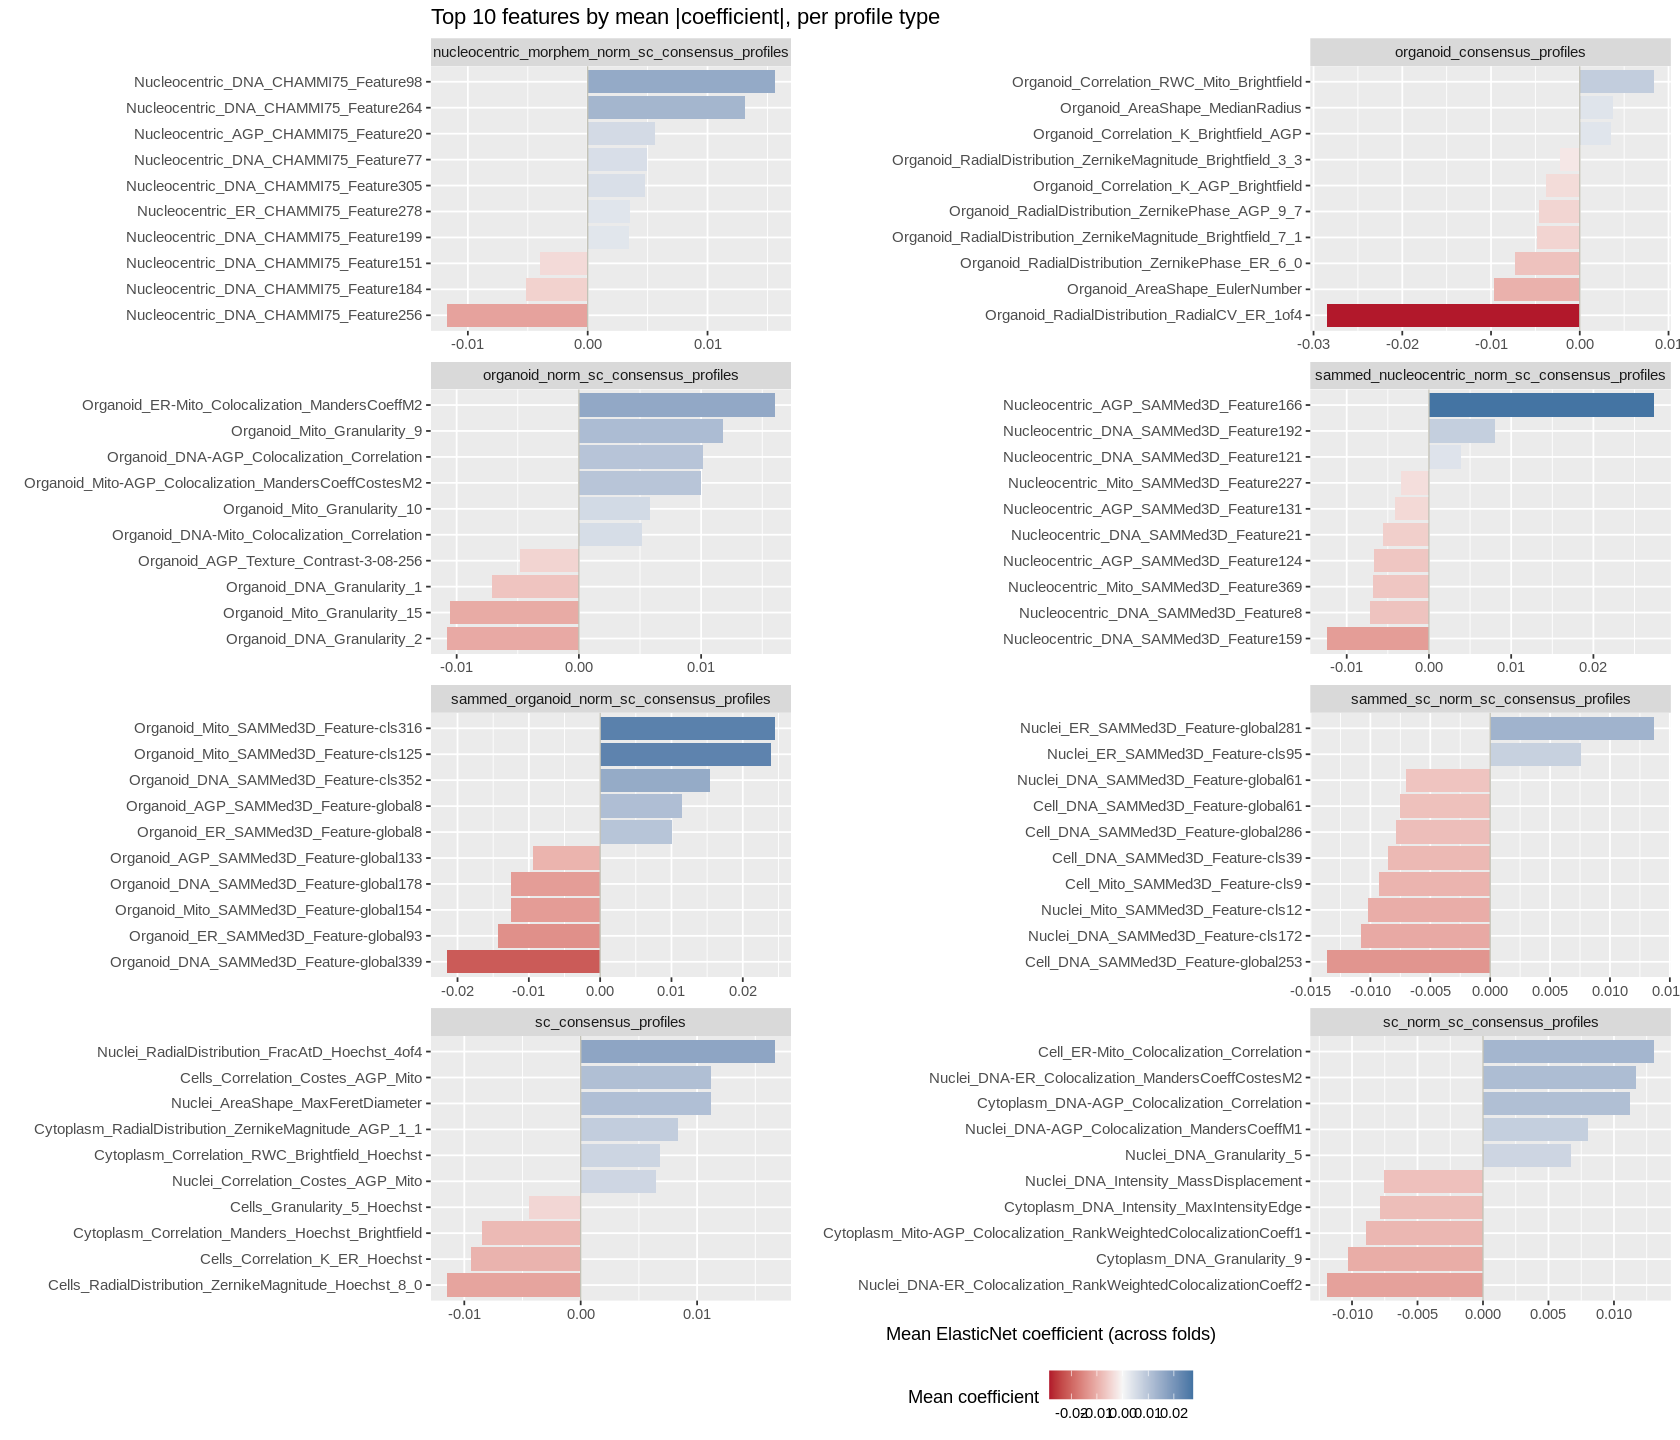

In [11]:
height <- 12
width <- 14
options(repr.plot.width = width, repr.plot.height = height)

# feature coefficients are a polarity, not a category or a magnitude alone -
# a diverging scale (not a categorical fill) is the correct encoding for
# "which direction did this feature push the prediction".
feature_importances_plot <- (
    ggplot(
        top_features_df,
        aes(x = reorder(feature, mean_importance), y = mean_importance, fill = mean_importance)
    )
    + geom_col()
    + geom_hline(yintercept = 0, color = "#c3c2b7", linewidth = 0.4)
    + facet_wrap(
        ~Metadata_profile_type, scales = "free", ncol = 2,
        labeller = label_wrap_gen(width = 30)
    )
    + coord_flip()
    + scale_fill_gradient2(
        low = "#B2182B",
        mid = "#F7F7F7",
        high = "#3B6FA0",
        midpoint = 0,
        name = "Mean coefficient"
    )
    + labs(
        x = NULL,
        y = "Mean ElasticNet coefficient (across folds)",
        title = "Top 10 features by mean |coefficient|, per profile type"
    )
    + theme(
        axis.text.y = element_text(size = 9),
        strip.text = element_text(size = 9),
        legend.position = "bottom"
    )
)
ggsave(filename = "top_feature_importances_by_profile.png", plot = feature_importances_plot, width = width, height = height)
feature_importances_plot

In [12]:
head(predicted_viabilities_df)

Metadata_Biology_PatientTumor,Metadata_Experiment_Treatment,Metadata_Experiment_Dose,Metadata_Experiment_Class,Metadata_Experiment_Target,Metadata_Experiment_TherapeuticCategories,Metadata_fold,Metadata_held_out_group,Metadata_split_method,Metadata_shuffle_status,Metadata_profile_type,Actual_Viability,Predicted_Viability,Metadata_feature_type,Metadata_profile_label,Metadata_2D_or_3D
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
NF0014_T1,Binimetinib,1,Small Molecule,MEK1/2 inhibitor,Kinase Inhibitor,0,NF0014_T1,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,0.7964860,0.7299943,Nucleocentric MorphEM,Nucleocentric MorphEM [Nucleocentric MorphEM],other
NF0014_T1,Binimetinib,1,Small Molecule,MEK1/2 inhibitor,Kinase Inhibitor,0,NF0014_T1,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,0.7964860,0.7299943,Nucleocentric MorphEM,Nucleocentric MorphEM [Nucleocentric MorphEM],other
NF0014_T1,Binimetinib,10,Small Molecule,MEK1/2 inhibitor,Kinase Inhibitor,0,NF0014_T1,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,0.7205708,0.7672985,Nucleocentric MorphEM,Nucleocentric MorphEM [Nucleocentric MorphEM],other
NF0014_T1,Binimetinib,10,Small Molecule,MEK1/2 inhibitor,Kinase Inhibitor,0,NF0014_T1,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,0.7205708,0.7672985,Nucleocentric MorphEM,Nucleocentric MorphEM [Nucleocentric MorphEM],other
NF0014_T1,Cabozantinib,1,Small Molecule,receptor tyrosine kinase inhibitor,Kinase Inhibitor,0,NF0014_T1,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,1.0000000,0.6331154,Nucleocentric MorphEM,Nucleocentric MorphEM [Nucleocentric MorphEM],other
NF0014_T1,Cabozantinib,1,Small Molecule,receptor tyrosine kinase inhibitor,Kinase Inhibitor,0,NF0014_T1,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,1.0000000,0.6331154,Nucleocentric MorphEM,Nucleocentric MorphEM [Nucleocentric MorphEM],other


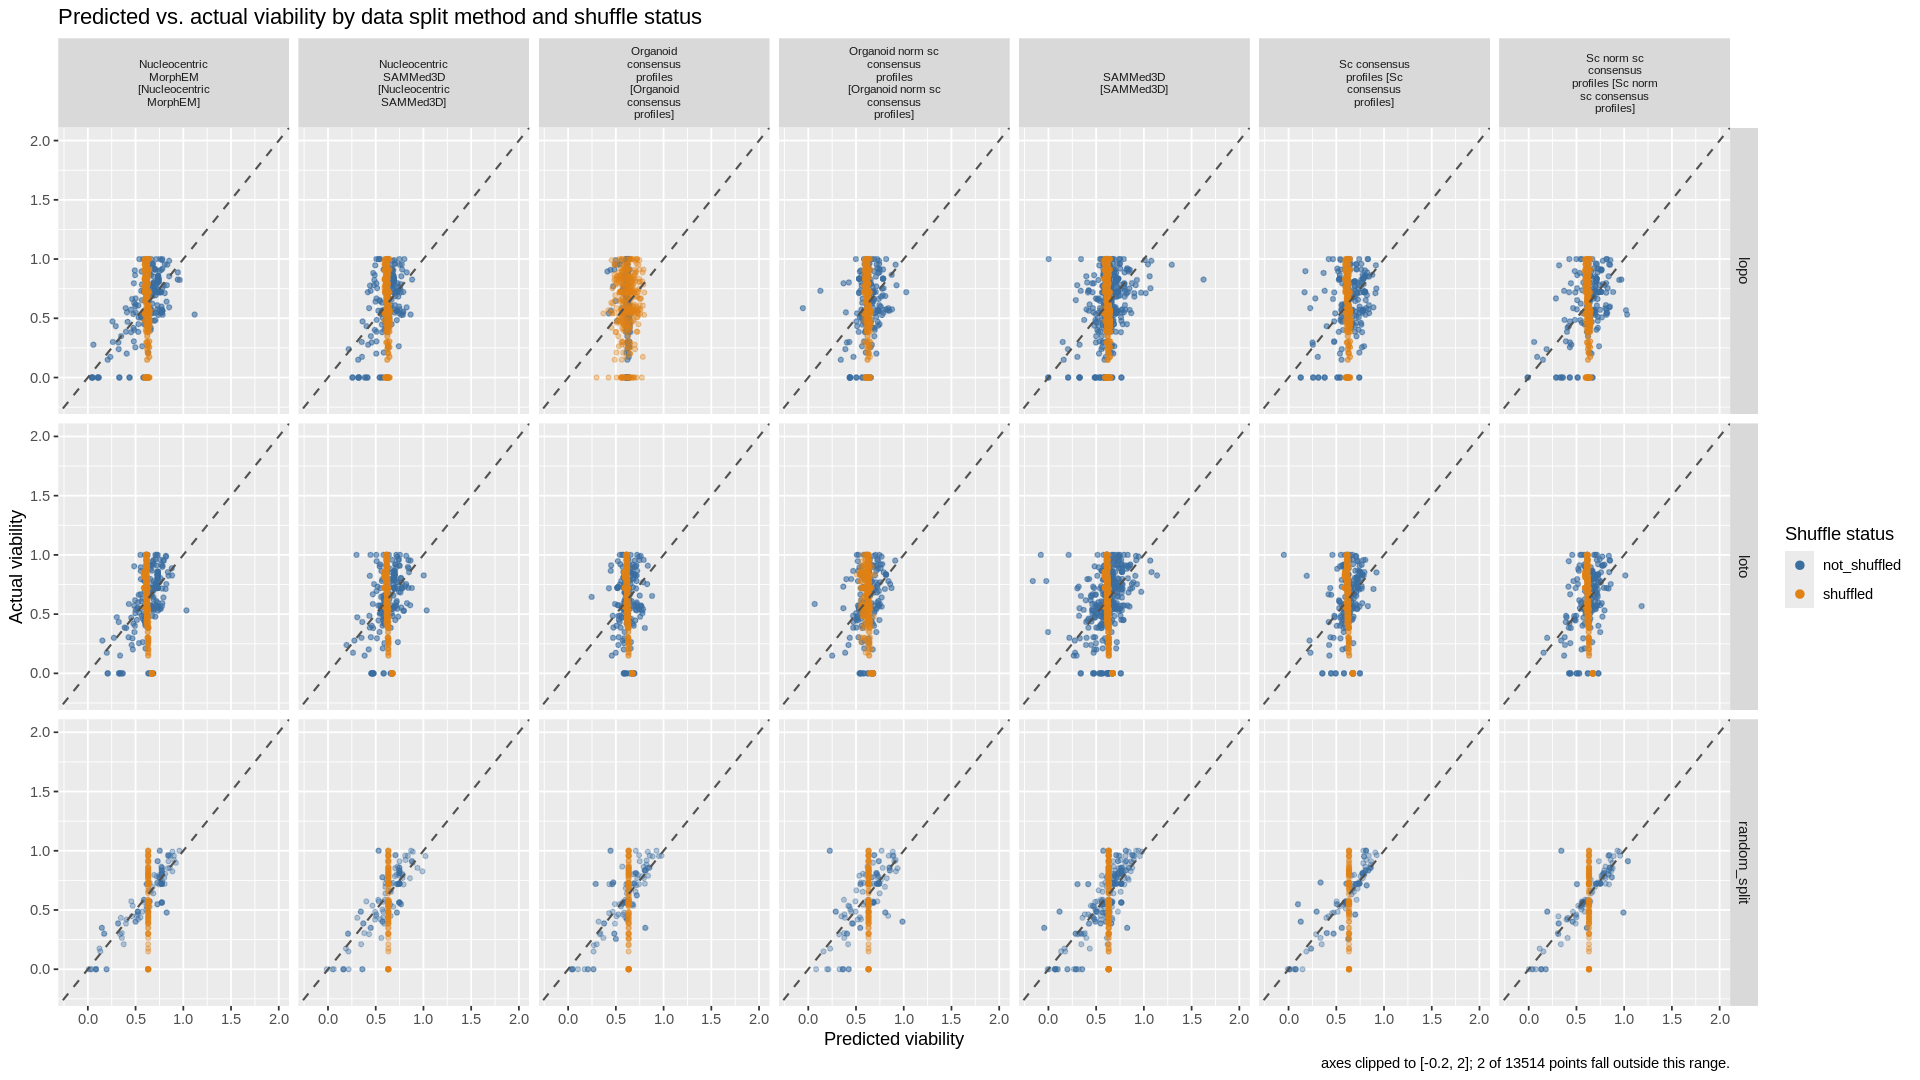

In [13]:
# predicted vs actual viability, one combined plot faceted by data split
# method (rows) x profile - labeled with its feature type (columns), with
# points colored by shuffle status so the not_shuffled fits and their
# shuffled-feature negative control sit in the same panel for direct
# comparison instead of separate figures.
#
# A few lopo folds predict wildly (up to ~2.5e13) - the same degenerate
# fits behind the R2/RMSE outliers above. Viability is stored as a 0-1
# fraction, not a 0-100 percentage (confirmed: Actual_Viability in
# combined_predicted_viabilities.parquet ranges [0, 1]), so clip the
# view to a generous [-0.2, 2] on that scale and disclose how many
# points fall outside it, rather than letting those points compress
# every real prediction into a single point at the origin.
options(repr.plot.width = 16, repr.plot.height = 9)

VIABILITY_LIM <- c(-0.2, 2)

shuffle_status_colors <- c(
    not_shuffled = "#3B6FA0",
    shuffled      = "#E08214"
)

n_clipped <- sum(
    predicted_viabilities_df$Predicted_Viability < VIABILITY_LIM[1] |
        predicted_viabilities_df$Predicted_Viability > VIABILITY_LIM[2],
    na.rm = TRUE
)

pred_vs_actual_plot <- (
    ggplot(
        predicted_viabilities_df,
        aes(x = Predicted_Viability, y = Actual_Viability, color = Metadata_shuffle_status)
    )
    + geom_point(alpha = 0.35, size = 1.1)
    + geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "#52514e", linewidth = 0.6)
    + facet_grid(
        Metadata_split_method ~ Metadata_profile_label,
        labeller = labeller(Metadata_profile_label = label_wrap_gen(width = 18))
    )
    + coord_cartesian(xlim = VIABILITY_LIM, ylim = VIABILITY_LIM)
    + scale_color_manual(values = shuffle_status_colors, name = "Shuffle status")
    + guides(color = guide_legend(override.aes = list(alpha = 1, size = 2)))
    + labs(
        x = "Predicted viability", y = "Actual viability",
        title = "Predicted vs. actual viability by data split method and shuffle status",
        caption = paste0(
            "axes clipped to [", VIABILITY_LIM[1], ", ", VIABILITY_LIM[2], "]; ",
            n_clipped, " of ", nrow(predicted_viabilities_df), " points fall outside this range."
        )
    )
    + theme(strip.text.x = element_text(size = 7), strip.text.y = element_text(size = 9))
)
ggsave(filename = "predicted_vs_actual.png", plot = pred_vs_actual_plot, width = 16, height = 9)
pred_vs_actual_plot